In [22]:
import pandas as pd
import numpy as np
import re

# df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv")
DATA_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv"   
TEXT_COL = "body"                          
TAGS_COL = "Tags"

df = pd.read_csv(DATA_PATH)

# Clean + split tags
df[TAGS_COL] = df[TAGS_COL].fillna("").astype(str).str.strip()
df["tag_list"] = df[TAGS_COL].apply(lambda x: [t.strip() for t in x.split(",")] if x != "" else [])

# Explode: one (post, tag) per row
df_exploded = df.explode("tag_list").rename(columns={"tag_list": "TW_category"})
df_exploded = df_exploded[df_exploded["TW_category"].notna()]
df_exploded["TW_category"] = df_exploded["TW_category"].astype(str).str.strip()

# OPTIONAL: remove empty tags
df_exploded = df_exploded[df_exploded["TW_category"] != ""]

# Show counts
print(df_exploded["TW_category"].value_counts())

TW_category
Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Not Applicable     862
Discrimination     526
Aggression         196
Name: count, dtype: int64


In [18]:
MAIN_TW = [
    "Mental Health",
    "Pregnancy",
    "Medical",
    "Abuse",
    "Sexual"
]

CONTROL = "Not Applicable"

df_tw_main = df_exploded[df_exploded["TW_category"].isin(MAIN_TW)].copy()
df_na = df_exploded[df_exploded["TW_category"] == CONTROL].copy()

print("Main TW rows:", len(df_tw_main))
print("Not Applicable rows:", len(df_na))
print(df_tw_main["TW_category"].value_counts())

Main TW rows: 10638
Not Applicable rows: 862
TW_category
Mental Health    3550
Pregnancy        2652
Medical          1815
Abuse            1703
Sexual            918
Name: count, dtype: int64


In [19]:
def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

## Emotion Analysis - NRC (Plutchik Emotions)

In [20]:
from collections import defaultdict

NRC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"  # update if needed

nrc = pd.read_csv(
    NRC_PATH,
    sep="\t",
    header=None,
    names=["word", "emotion", "association"]
)

nrc = nrc[nrc["association"] == 1]

emotion_lex = defaultdict(set)
for _, row in nrc.iterrows():
    emotion_lex[row["emotion"]].add(row["word"])

EMOTIONS = ["anger","fear","sadness","disgust","anticipation","trust","joy","surprise"]
print("Loaded NRC emotions:", EMOTIONS)

Loaded NRC emotions: ['anger', 'fear', 'sadness', 'disgust', 'anticipation', 'trust', 'joy', 'surprise']


In [23]:
def emotion_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {emo: sum(t in emotion_lex[emo] for t in tokens) / n for emo in EMOTIONS}

emo_df = df_tw_main[TEXT_COL].apply(emotion_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, emo_df], axis=1)

emotion_by_tw = df_tw_main.groupby("TW_category")[EMOTIONS].mean()
emotion_by_tw

,anger,fear,sadness,disgust,anticipation,trust,joy,surprise
TW_category,,,,,,,,
Abuse,0.015303,0.018493,0.018634,0.012386,0.019171,0.025910,0.015271,0.007182
Medical,0.009949,0.028559,0.029134,0.018637,0.021519,0.024986,0.016232,0.007707
Mental Health,0.013215,0.023386,0.024820,0.015546,0.021340,0.025940,0.017498,0.007892
Pregnancy,0.011193,0.027642,0.029145,0.018586,0.022560,0.026236,0.018798,0.008080
Sexual,0.013538,0.017504,0.017501,0.012103,0.021444,0.025605,0.016190,0.006785


## Pronoun Usage per TW Category

In [24]:
FIRST = {"i","me","my","mine","myself"}
SECOND = {"you","your","yours","yourself"}
THIRD = {"he","she","they","them","his","her","their","theirs"}

def pronoun_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {
        "first_person": sum(t in FIRST for t in tokens) / n,
        "second_person": sum(t in SECOND for t in tokens) / n,
        "third_person": sum(t in THIRD for t in tokens) / n,
    }

pro_df = df_tw_main[TEXT_COL].apply(pronoun_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, pro_df], axis=1)

pron_by_tw = df_tw_main.groupby("TW_category")[["first_person","second_person","third_person"]].mean()
pron_by_tw

,first_person,second_person,third_person
TW_category,,,
Abuse,0.105564,0.004056,0.035509
Medical,0.089756,0.004747,0.012934
Mental Health,0.099547,0.004693,0.024043
Pregnancy,0.091547,0.005778,0.016070
Sexual,0.106757,0.003555,0.035516


## Verb Tense per TW Category

In [25]:
import spacy
nlp = spacy.load("en_core_web_sm")

def tense_features(text):
    doc = nlp(str(text))
    past = present = future = 0

    for tok in doc:
        if tok.pos_ == "VERB":
            if "Tense=Past" in tok.morph:
                past += 1
            elif "Tense=Pres" in tok.morph:
                present += 1

        # simple future markers (lightweight)
        if tok.lower_ in {"will", "gonna"}:
            future += 1

    total = max(past + present + future, 1)
    return {
        "past": past / total,
        "present": present / total,
        "future": future / total
    }

tense_df = df_tw_main[TEXT_COL].apply(tense_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, tense_df], axis=1)

tense_by_tw = df_tw_main.groupby("TW_category")[["past","present","future"]].mean()
tense_by_tw

,past,present,future
TW_category,,,
Abuse,0.539487,0.447343,0.010234
Medical,0.510262,0.470527,0.015905
Mental Health,0.498549,0.487169,0.013719
Pregnancy,0.474073,0.503788,0.017614
Sexual,0.560684,0.429582,0.008644


## Bodily / Sensory Language per TW Category

In [26]:
BODY_WORDS = {
    "pain","hurt","blood","bleeding","cramps","injury","wound","bruise",
    "stomach","head","chest","throat","skin","body","vomit","nausea"
}

def body_ratio(text):
    tokens = tokenize(text)
    return sum(t in BODY_WORDS for t in tokens) / max(len(tokens), 1)

df_tw_main["body_ratio"] = df_tw_main[TEXT_COL].apply(body_ratio)

body_by_tw = df_tw_main.groupby("TW_category")["body_ratio"].mean()
body_by_tw

TW_category
Abuse            0.002294
Medical          0.010335
Mental Health    0.005150
Pregnancy        0.007557
Sexual           0.003050
Name: body_ratio, dtype: float64

## TW vs NA

In [27]:
# Create a combined TW dataframe (all main TW rows) + NA rows
df_control = pd.concat([
    df_tw_main.assign(group="TW"),
    df_na.assign(group="Not Applicable")
], axis=0)

# If NRC/pronoun/tense/body weren’t computed for df_na yet, compute them quickly:

# emotions for NA
emo_na = df_na[TEXT_COL].apply(emotion_features).apply(pd.Series)
pro_na = df_na[TEXT_COL].apply(pronoun_features).apply(pd.Series)
ten_na = df_na[TEXT_COL].apply(tense_features).apply(pd.Series)
body_na = df_na[TEXT_COL].apply(body_ratio)

df_na_feats = pd.concat([df_na, emo_na, pro_na, ten_na], axis=1)
df_na_feats["body_ratio"] = body_na
df_na_feats["group"] = "Not Applicable"

df_tw_feats = df_tw_main.copy()
df_tw_feats["group"] = "TW"

df_control_feats = pd.concat([df_tw_feats, df_na_feats], axis=0)

control_emotions = df_control_feats.groupby("group")[EMOTIONS].mean()
control_pronouns = df_control_feats.groupby("group")[["first_person","second_person","third_person"]].mean()
control_tense = df_control_feats.groupby("group")[["past","present","future"]].mean()
control_body = df_control_feats.groupby("group")[["body_ratio"]].mean()

control_emotions, control_pronouns, control_tense, control_body

(                   anger      fear   sadness   disgust  anticipation  \
 group                                                                  
 Not Applicable  0.014045  0.016382  0.017113  0.011409      0.018664   
 TW              0.012516  0.024039  0.025012  0.016028      0.021337   
 
                    trust       joy  surprise  
 group                                         
 Not Applicable  0.025585  0.016719  0.008051  
 TW              0.025817  0.017137  0.007698  ,
                 first_person  second_person  third_person
 group                                                    
 Not Applicable      0.076250       0.006899      0.032092
 TW                  0.097468       0.004772      0.022986,
                     past   present    future
 group                                       
 Not Applicable  0.522008  0.455810  0.016382
 TW              0.506361  0.477128  0.014067,
                 body_ratio
 group                     
 Not Applicable    0.002040
 TW    

# Plots

## Radar Plot

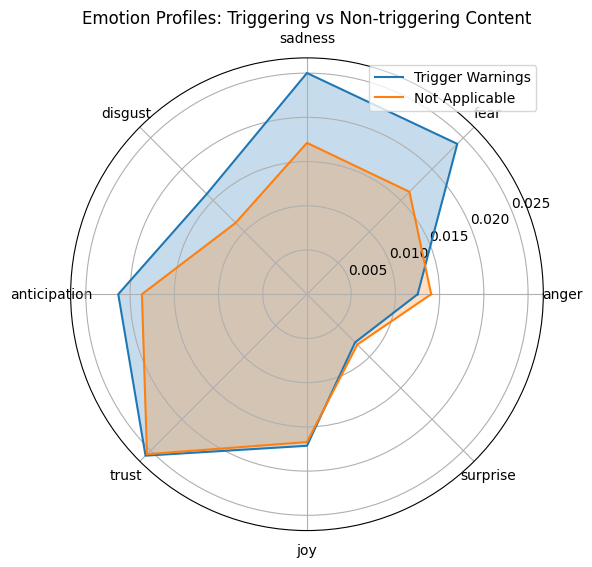

In [37]:
import numpy as np
import matplotlib.pyplot as plt

labels = EMOTIONS
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

def radar_vals(row):
    vals = row.values.tolist()
    return vals + vals[:1]

tw_vals = radar_vals(control_emotions.loc["TW"])
na_vals = radar_vals(control_emotions.loc["Not Applicable"])

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, tw_vals, label="Trigger Warnings")
ax.fill(angles, tw_vals, alpha=0.25)

ax.plot(angles, na_vals, label="Not Applicable")
ax.fill(angles, na_vals, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Emotion Profiles: Triggering vs Non-triggering Content")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("fig_emotion_radar_tw_vs_na.pdf", bbox_inches="tight")
plt.show()

In [31]:
emotion_by_tw.index
tense_by_tw.index
pron_by_tw.index
body_by_tw.index

Index(['Abuse', 'Medical', 'Mental Health', 'Pregnancy', 'Sexual'], dtype='object', name='TW_category')

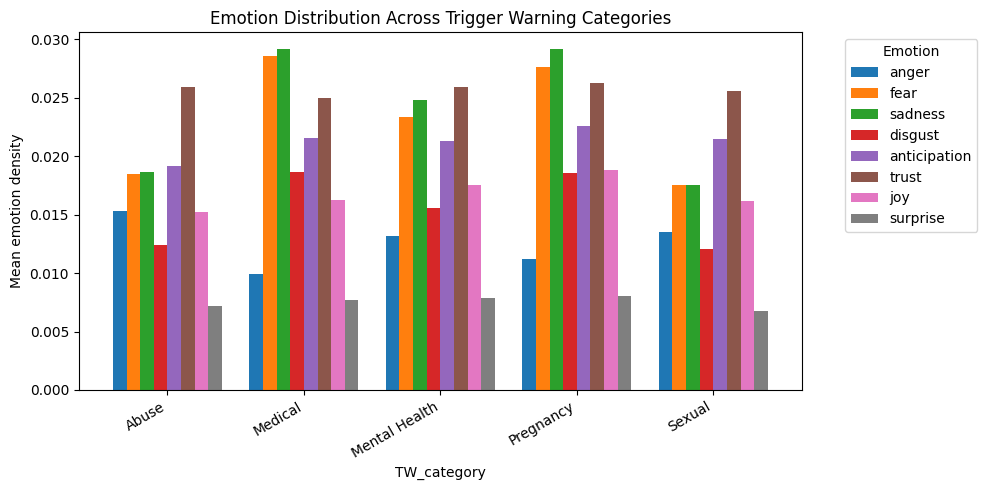

In [36]:
import matplotlib.pyplot as plt

emotion_by_tw.plot(
    kind="bar",
    figsize=(10,5),
    width=0.8
)

plt.ylabel("Mean emotion density")
plt.title("Emotion Distribution Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Emotion", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig(
    "emotion_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

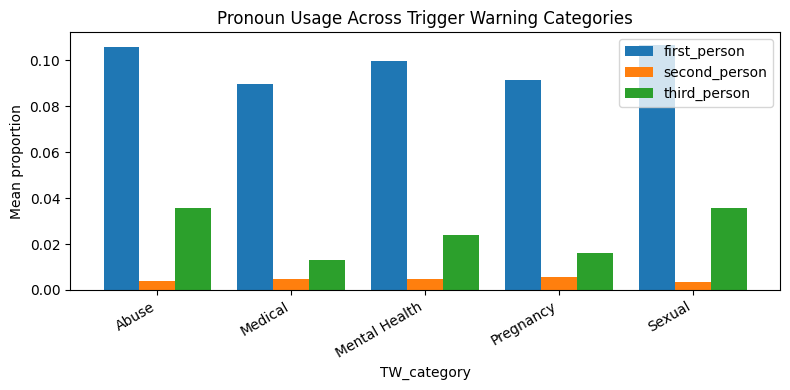

In [38]:
pron_by_tw.plot(
    kind="bar",
    figsize=(8,4),
    width=0.8
)

plt.ylabel("Mean proportion")
plt.title("Pronoun Usage Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(
    "pron_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

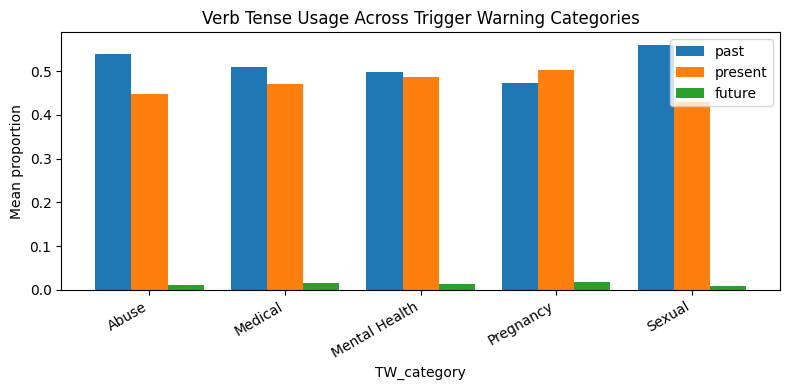

In [39]:
tense_by_tw.plot(
    kind="bar",
    figsize=(8,4),
    width=0.8
)

plt.ylabel("Mean proportion")
plt.title("Verb Tense Usage Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(
    "tense_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

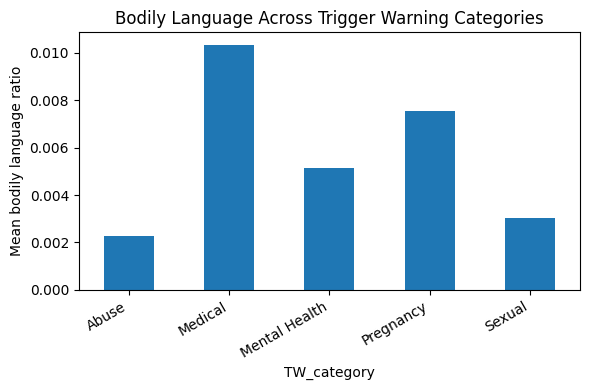

In [40]:
body_by_tw.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("Mean bodily language ratio")
plt.title("Bodily Language Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    "body_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()